# 🍷 Classificação de Qualidade de Vinhos com Machine Learning
**POSTECH - Data Analytics | Tech Challenge - Fase 2**

---
## Etapas
1. Compreensão do Problema
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento
4. Desenvolvimento dos Modelos
5. Avaliação e Comparação
6. Interpretação dos Resultados

## 0. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


---
## 1. Compreensão do Problema

A indústria vinícola depende de avaliações sensoriais feitas por especialistas — um processo subjetivo e caro.
O objetivo deste projeto é criar um modelo de Machine Learning capaz de **prever a qualidade de um vinho** com base em suas características físico-químicas.

### Variável Alvo (Target)
A coluna `quality` contém notas de 0 a 10 dadas por especialistas. Vamos transformá-la em **classificação binária**:
- **Alta Qualidade (1)**: nota ≥ 7
- **Baixa/Média Qualidade (0)**: nota < 7

In [4]:
# Carregando o dataset
df = pd.read_csv('WineQT.csv')

print(f'Shape do dataset: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head()

Shape do dataset: (1143, 13)

Primeiras linhas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [5]:
# Removendo coluna Id (não é uma feature)
df = df.drop(columns=['Id'])

# Criando a variável binária
df['quality_label'] = (df['quality'] >= 7).astype(int)

print('Distribuição original das notas de qualidade:')
print(df['quality'].value_counts().sort_index())
print(f'\nDistribuição da variável binária:')
print(df['quality_label'].value_counts())
print(f'\nProporção: {df["quality_label"].mean():.1%} de vinhos de alta qualidade')

Distribuição original das notas de qualidade:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuição da variável binária:
quality_label
0    984
1    159
Name: count, dtype: int64

Proporção: 13.9% de vinhos de alta qualidade


---
## 2. Análise Exploratória de Dados (EDA)

In [6]:
# Informações gerais
print('=== Informações Gerais ===')
df.info()
print('\n=== Valores Nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Informações Gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  quality_label         1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

=== Valores Nulos ===
fixed acidity           0

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,0.14
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,0.35
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,0.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,0.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,0.00
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1.00


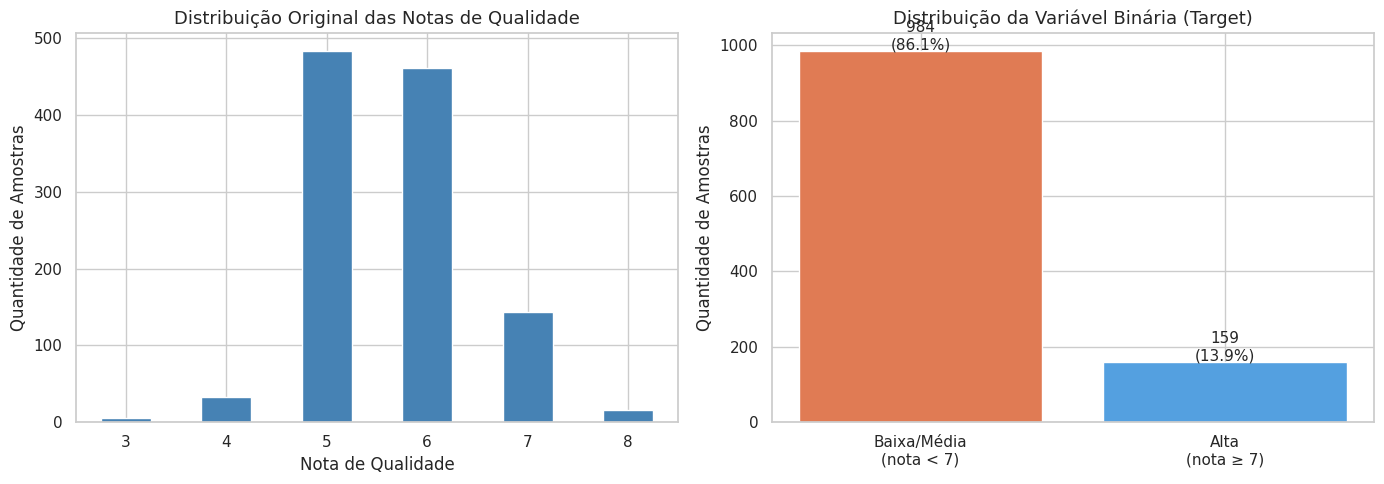

⚠️  Dataset desbalanceado: maioria das amostras é de baixa/média qualidade.


In [8]:
# Balanceamento das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição Original das Notas de Qualidade', fontsize=13)
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Amostras')
axes[0].tick_params(axis='x', rotation=0)

# Classes binárias
labels = ['Baixa/Média\n(nota < 7)', 'Alta\n(nota ≥ 7)']
counts = df['quality_label'].value_counts().sort_index()
bars = axes[1].bar(labels, counts, color=['#e07b54', '#54a0e0'], edgecolor='white')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}\n({count/len(df):.1%})', ha='center', fontsize=11)
axes[1].set_title('Distribuição da Variável Binária (Target)', fontsize=13)
axes[1].set_ylabel('Quantidade de Amostras')

plt.tight_layout()
plt.show()
print('⚠️  Dataset desbalanceado: maioria das amostras é de baixa/média qualidade.')

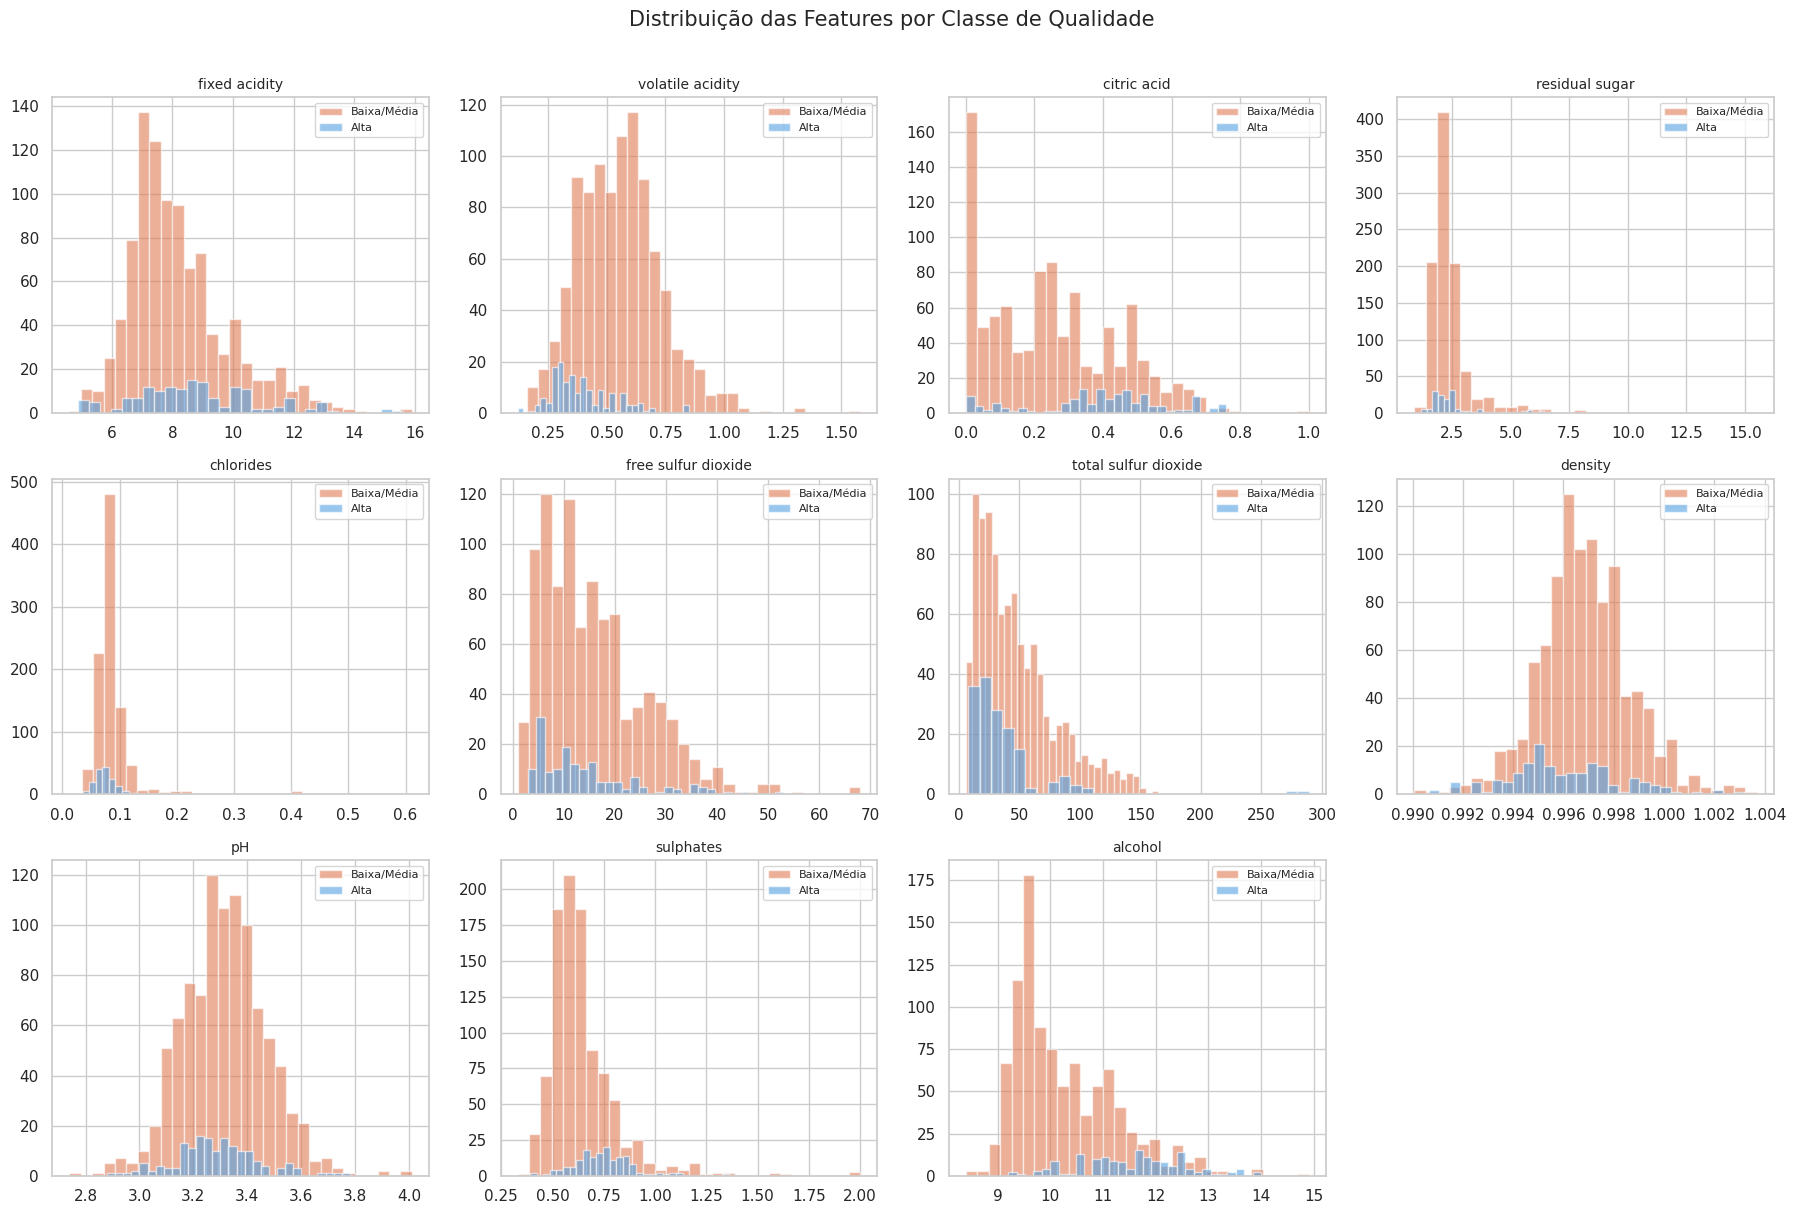

In [9]:
# Distribuição de cada feature
features = [c for c in df.columns if c not in ['quality', 'quality_label']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    df[df['quality_label']==0][feat].hist(ax=axes[i], bins=30, alpha=0.6,
                                           color='#e07b54', label='Baixa/Média')
    df[df['quality_label']==1][feat].hist(ax=axes[i], bins=30, alpha=0.6,
                                           color='#54a0e0', label='Alta')
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)

# Remove eixos extras
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

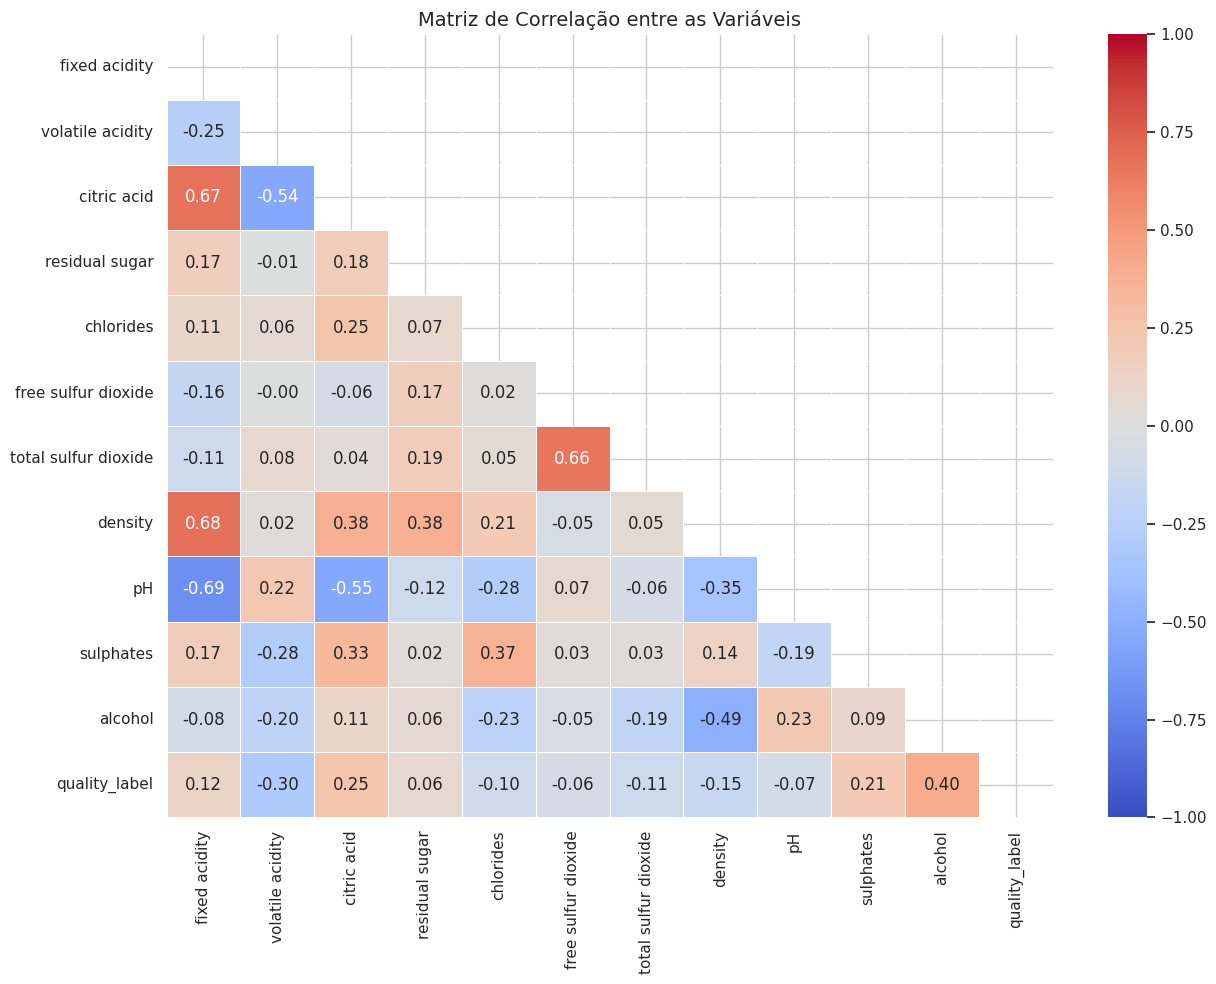


Correlação de cada feature com a qualidade (binária):
alcohol                 0.404
volatile acidity       -0.305
citric acid             0.251
sulphates               0.208
density                -0.149
fixed acidity           0.123
total sulfur dioxide   -0.113
chlorides              -0.104
pH                     -0.073
residual sugar          0.064
free sulfur dioxide    -0.056
Name: quality_label, dtype: float64


In [11]:
# Matriz de correlação
plt.figure(figsize=(13, 10))
corr = df[features + ['quality_label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre as Variáveis', fontsize=14)
plt.tight_layout()
plt.show()

# Correlações com o target
print('\nCorrelação de cada feature com a qualidade (binária):')
target_corr = corr['quality_label'].drop('quality_label').sort_values(key=abs, ascending=False)
print(target_corr.round(3))

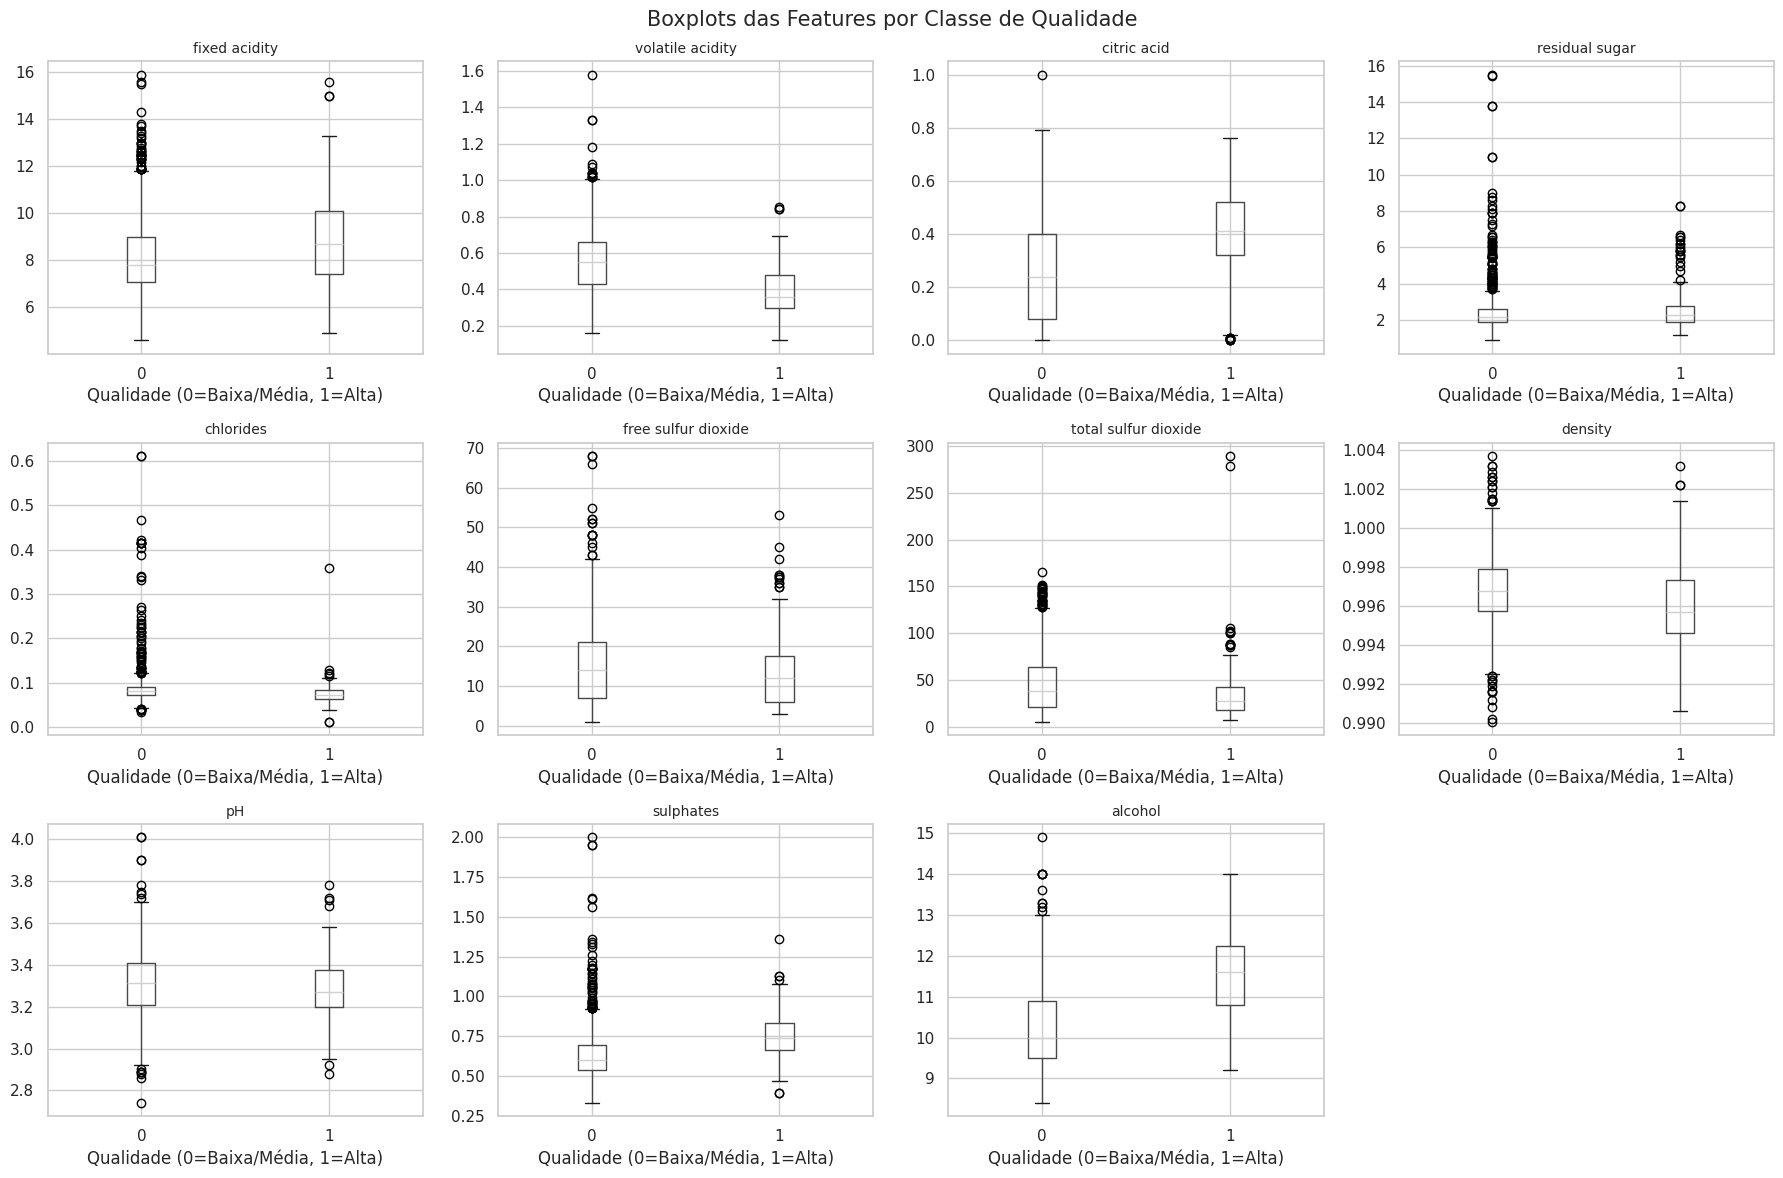

In [13]:
# Análise de outliers com boxplots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='quality_label', ax=axes[i])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Qualidade (0=Baixa/Média, 1=Alta)')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots das Features por Classe de Qualidade', fontsize=15)
plt.tight_layout()
plt.show()

In [14]:
# Insights da EDA
print('=== 📊 PRINCIPAIS INSIGHTS DA EDA ===')
print()
print('1. BALANCEAMENTO: Dataset desbalanceado — ~86% baixa/média qualidade, ~14% alta qualidade.')
print('   → Estratégia: usar class_weight="balanced" nos modelos e métricas como F1 e ROC-AUC.')
print()
print('2. ALCOHOL: Maior correlação positiva com alta qualidade.')
print('   → Vinhos de alta qualidade tendem a ter maior teor alcoólico.')
print()
print('3. VOLATILE ACIDITY: Maior correlação negativa — acidez volátil alta prejudica a qualidade.')
print('   → Acidez volátil alta indica defeitos fermentativos (vinagre).')
print()
print('4. SULPHATES e CITRIC ACID: Correlação positiva com qualidade.')
print('   → Atuam como conservantes e contribuem para frescor e complexidade.')
print()
print('5. OUTLIERS: Presença de outliers em chlorides, residual sugar e sulfur dioxide.')
print('   → Serão tratados via padronização (StandardScaler).')

=== 📊 PRINCIPAIS INSIGHTS DA EDA ===

1. BALANCEAMENTO: Dataset desbalanceado — ~86% baixa/média qualidade, ~14% alta qualidade.
   → Estratégia: usar class_weight="balanced" nos modelos e métricas como F1 e ROC-AUC.

2. ALCOHOL: Maior correlação positiva com alta qualidade.
   → Vinhos de alta qualidade tendem a ter maior teor alcoólico.

3. VOLATILE ACIDITY: Maior correlação negativa — acidez volátil alta prejudica a qualidade.
   → Acidez volátil alta indica defeitos fermentativos (vinagre).

4. SULPHATES e CITRIC ACID: Correlação positiva com qualidade.
   → Atuam como conservantes e contribuem para frescor e complexidade.

5. OUTLIERS: Presença de outliers em chlorides, residual sugar e sulfur dioxide.
   → Serão tratados via padronização (StandardScaler).


---
## 3. Pré-processamento de Dados

In [15]:
# Definindo features e target
X = df[features].copy()
y = df['quality_label'].copy()

print(f'Features: {list(X.columns)}')
print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Shape X: (1143, 11)
Shape y: (1143,)


In [16]:
# Feature Engineering: criando features adicionais
X['free_to_total_SO2'] = X['free sulfur dioxide'] / (X['total sulfur dioxide'] + 1e-9)  # razão SO2 livre/total
X['acidity_ratio'] = X['fixed acidity'] / (X['volatile acidity'] + 1e-9)  # razão acidez fixa/volátil

print('✅ Features criadas:')
print('  - free_to_total_SO2: proporção de dióxido de enxofre livre (conservação ativa)')
print('  - acidity_ratio: razão entre acidez fixa e volátil (equilíbrio de acidez)')
print(f'\nShape final de X: {X.shape}')

✅ Features criadas:
  - free_to_total_SO2: proporção de dióxido de enxofre livre (conservação ativa)
  - acidity_ratio: razão entre acidez fixa e volátil (equilíbrio de acidez)

Shape final de X: (1143, 13)


In [17]:
# Divisão treino/teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')
print(f'\nProporção de alta qualidade no treino: {y_train.mean():.1%}')
print(f'Proporção de alta qualidade no teste:  {y_test.mean():.1%}')

Treino: 914 amostras
Teste:  229 amostras

Proporção de alta qualidade no treino: 13.9%
Proporção de alta qualidade no teste:  14.0%


In [18]:
# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Normalização aplicada (StandardScaler)')
print('   Média de treino (deve ser ~0):', X_train_scaled.mean().round(4))
print('   Desvio-padrão de treino (deve ser ~1):', X_train_scaled.std().round(4))

✅ Normalização aplicada (StandardScaler)
   Média de treino (deve ser ~0): 0.0
   Desvio-padrão de treino (deve ser ~1): 1.0


---
## 4. Desenvolvimento dos Modelos

Vamos treinar **3 modelos** para comparação:
1. **Regressão Logística** — modelo linear, baseline interpretável
2. **Random Forest** — ensemble de árvores, robusto a outliers
3. **Gradient Boosting** — ensemble sequencial, geralmente alta performance

In [19]:
# Definindo os modelos
models = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    )
}

# Treinar e avaliar com Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    # Regressão Logística usa dados normalizados
    X_cv = X_train_scaled if name == 'Regressão Logística' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

Regressão Logística: ROC-AUC = 0.8683 ± 0.0368
Random Forest: ROC-AUC = 0.9179 ± 0.0238
Gradient Boosting: ROC-AUC = 0.9127 ± 0.0252


In [20]:
# Treinando os modelos no conjunto de treino completo
trained_models = {}
for name, model in models.items():
    X_tr = X_train_scaled if name == 'Regressão Logística' else X_train
    model.fit(X_tr, y_train)
    trained_models[name] = model
    print(f'✅ {name} treinado')

✅ Regressão Logística treinado
✅ Random Forest treinado
✅ Gradient Boosting treinado


---
## 5. Avaliação dos Modelos

In [21]:
# Métricas no conjunto de teste
results = []
predictions = {}

for name, model in trained_models.items():
    X_te = X_test_scaled if name == 'Regressão Logística' else X_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    predictions[name] = (y_pred, y_prob)

    results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Modelo')
print('=== Métricas no Conjunto de Teste ===')
results_df.round(4)

=== Métricas no Conjunto de Teste ===


,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.7904,0.3621,0.6562,0.4667,0.8634
Random Forest,0.9083,0.7200,0.5625,0.6316,0.9013
Gradient Boosting,0.9170,0.7241,0.6562,0.6885,0.8871


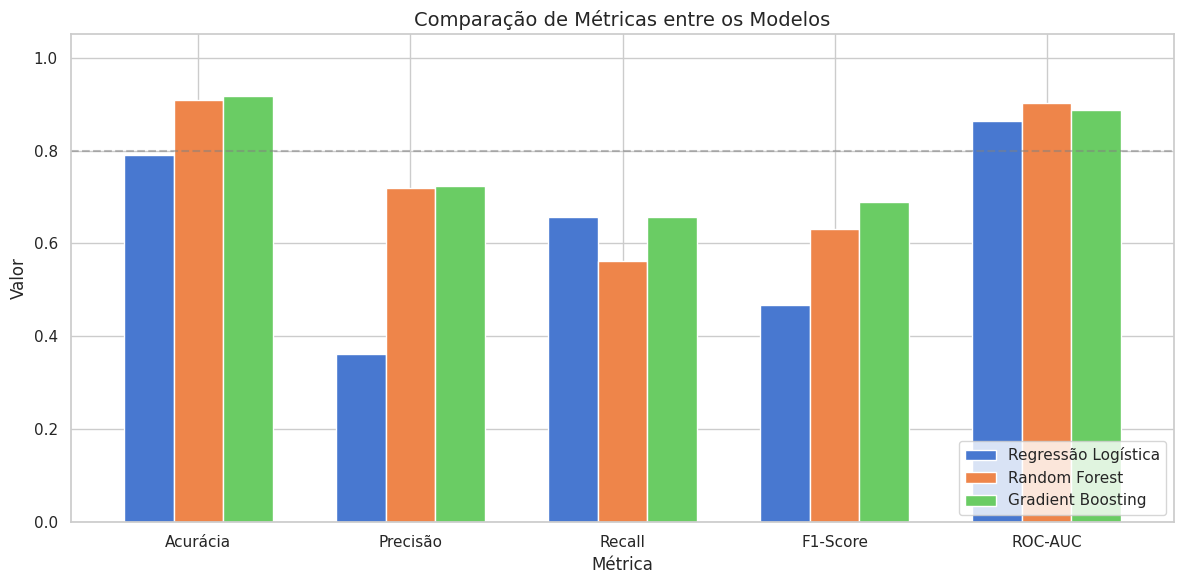

In [22]:
# Visualização comparativa das métricas
fig, ax = plt.subplots(figsize=(12, 6))
results_df.T.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Comparação de Métricas entre os Modelos', fontsize=14)
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Referência 0.8')
plt.tight_layout()
plt.show()

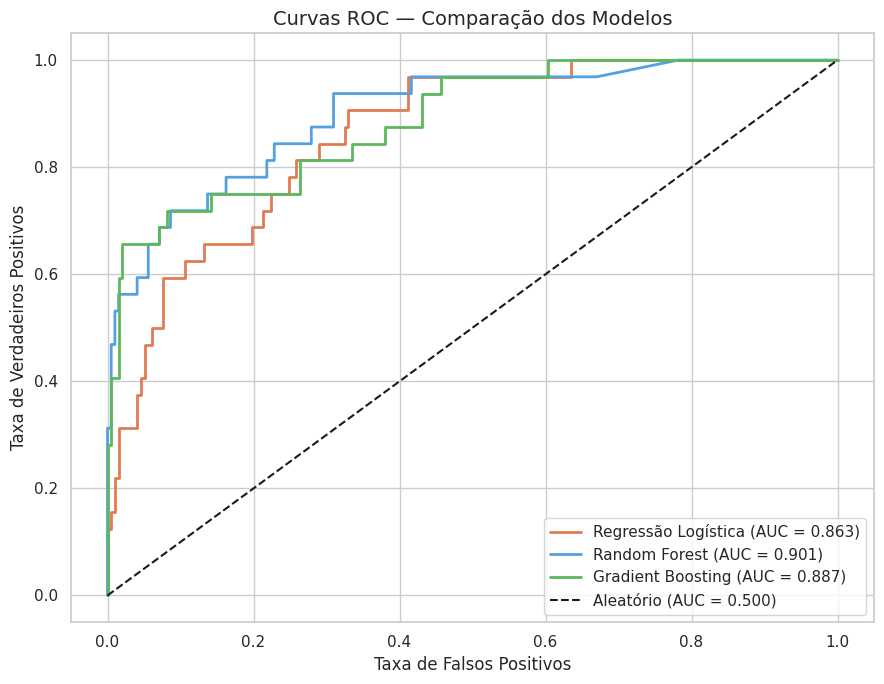

In [24]:
# Curvas ROC
plt.figure(figsize=(9, 7))
colors = ['#e07b54', '#54a0e0', '#5cb85c']

for (name, (y_pred, y_prob)), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.500)')
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curvas ROC — Comparação dos Modelos', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

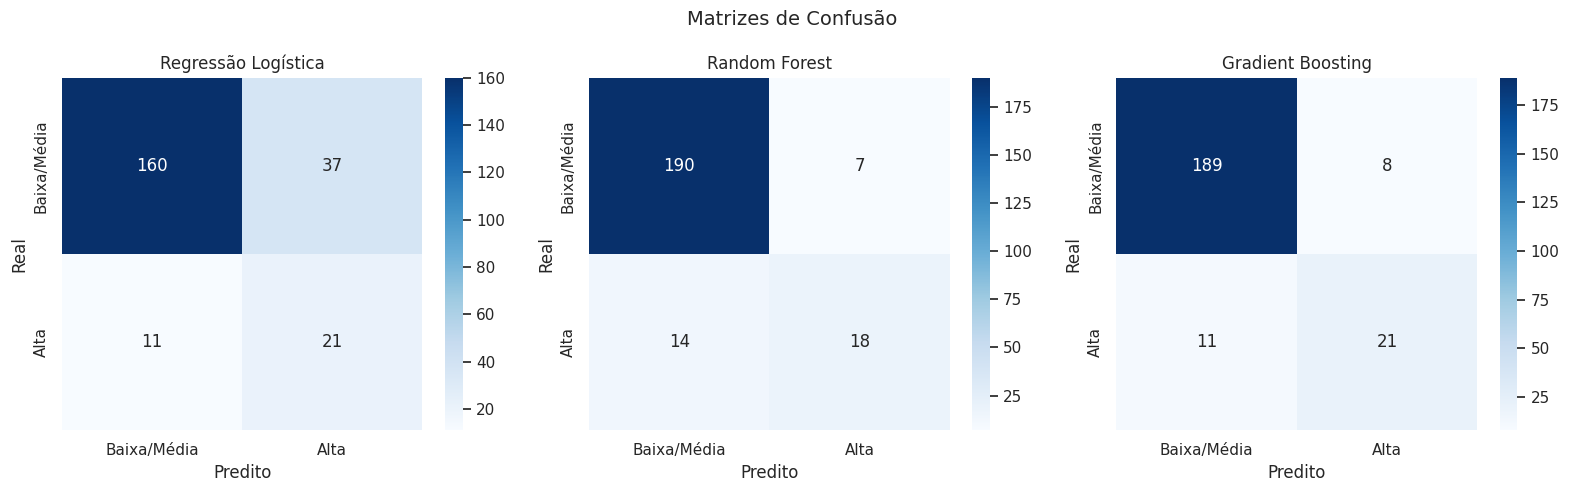

In [26]:
# Matrizes de confusão dos 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, (y_pred, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baixa/Média', 'Alta'],
                yticklabels=['Baixa/Média', 'Alta'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
# Relatórios detalhados
for name, (y_pred, _) in predictions.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred,
                                target_names=['Baixa/Média Qualidade', 'Alta Qualidade']))


=== Regressão Logística ===
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.94      0.81      0.87       197
       Alta Qualidade       0.36      0.66      0.47        32

             accuracy                           0.79       229
            macro avg       0.65      0.73      0.67       229
         weighted avg       0.86      0.79      0.81       229


=== Random Forest ===
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.93      0.96      0.95       197
       Alta Qualidade       0.72      0.56      0.63        32

             accuracy                           0.91       229
            macro avg       0.83      0.76      0.79       229
         weighted avg       0.90      0.91      0.90       229


=== Gradient Boosting ===
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.94      0.96      0.95       197
       Alta Qualidade       0.72

---
## 6. Interpretação dos Resultados

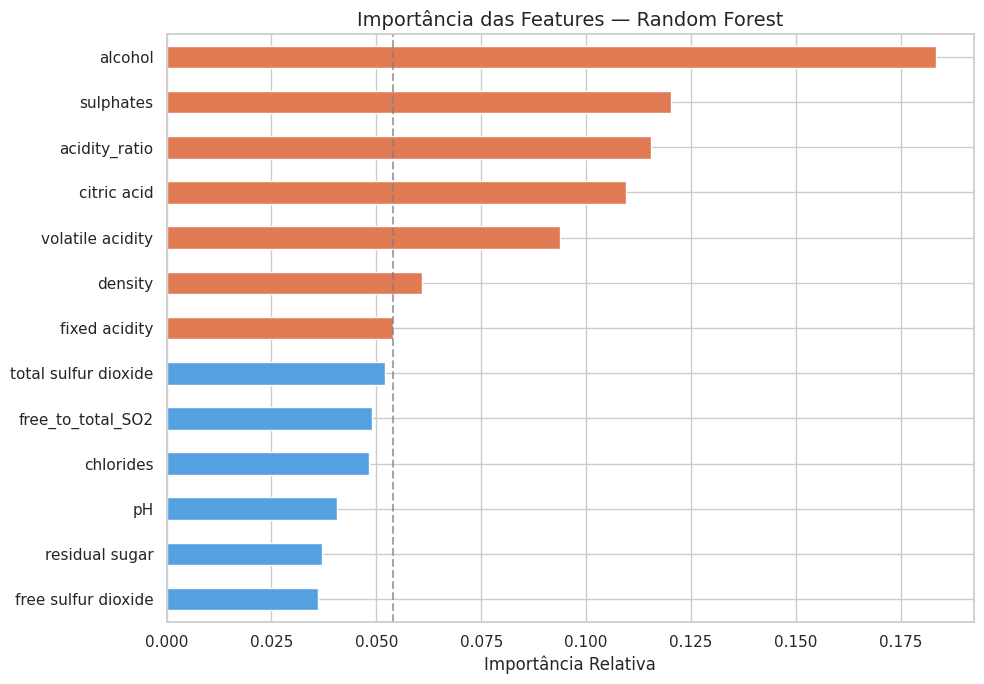

In [28]:
# Importância das features — Random Forest
rf_model = trained_models['Random Forest']
feat_names = list(X.columns)
importances = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#54a0e0' if v < importances.median() else '#e07b54' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Importância das Features — Random Forest', fontsize=14)
plt.xlabel('Importância Relativa')
plt.axvline(importances.median(), color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

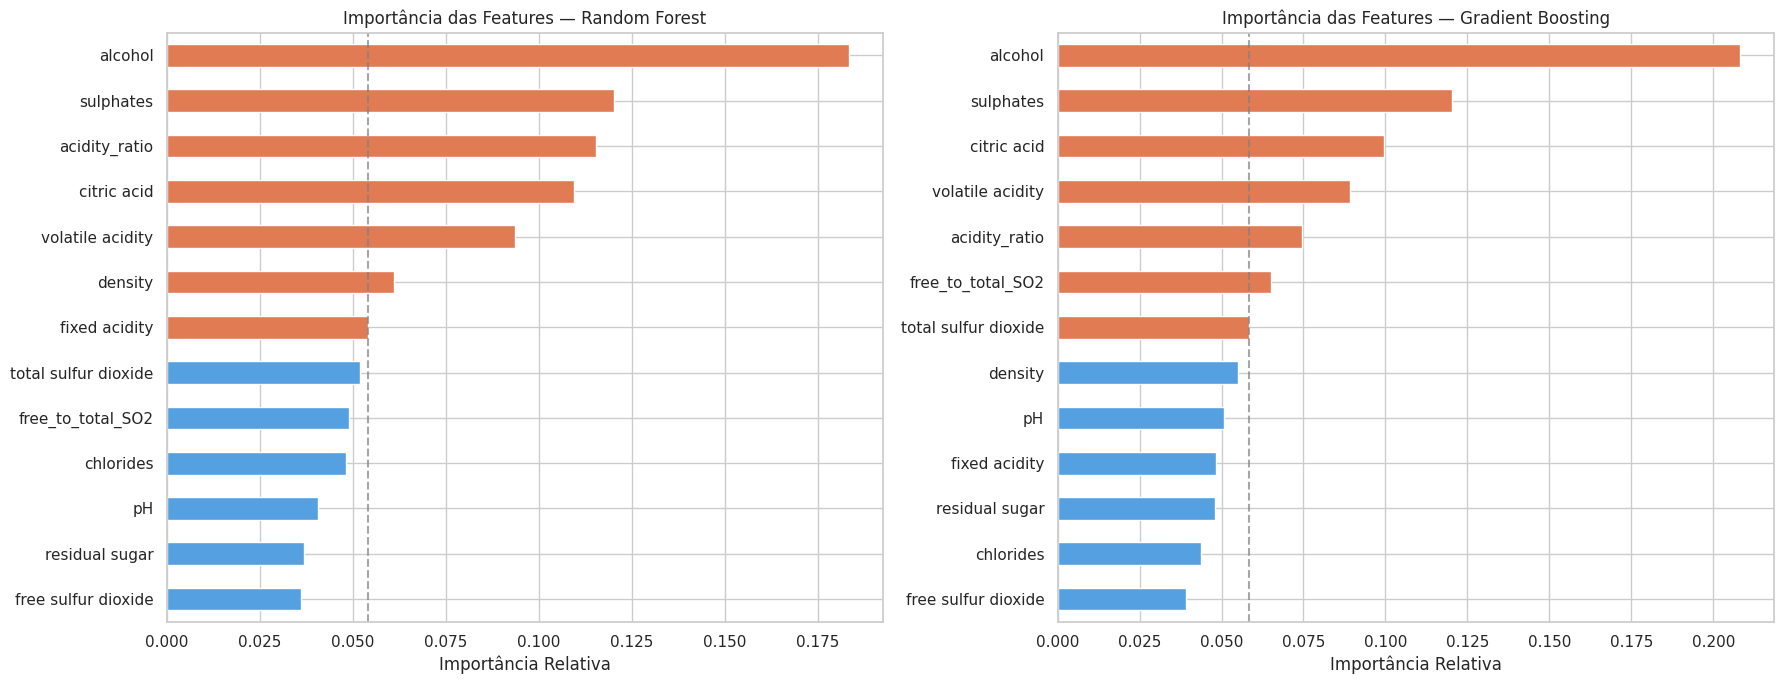

In [29]:
# Importância das features — Gradient Boosting
gb_model = trained_models['Gradient Boosting']
importances_gb = pd.Series(gb_model.feature_importances_, index=feat_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (imp, title) in zip(axes, [
    (importances, 'Random Forest'),
    (importances_gb, 'Gradient Boosting')
]):
    colors = ['#54a0e0' if v < imp.median() else '#e07b54' for v in imp]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Importância das Features — {title}', fontsize=12)
    ax.set_xlabel('Importância Relativa')
    ax.axvline(imp.median(), color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# Resumo Final
best_model_name = results_df['ROC-AUC'].idxmax()
best_auc = results_df.loc[best_model_name, 'ROC-AUC']
best_f1 = results_df.loc[best_model_name, 'F1-Score']

top_features = importances_gb.sort_values(ascending=False).head(5)

print('=' * 55)
print('        📊 RESUMO EXECUTIVO DOS RESULTADOS')
print('=' * 55)
print(f'\n🏆 Melhor modelo: {best_model_name}')
print(f'   ROC-AUC: {best_auc:.4f}')
print(f'   F1-Score: {best_f1:.4f}')
print()
print('🔑 Top 5 variáveis mais importantes (Gradient Boosting):')
for i, (feat, val) in enumerate(top_features.items(), 1):
    print(f'   {i}. {feat}: {val:.4f}')
print()
print('💡 Implicações para a produção:')
print('   • Monitorar o teor alcoólico (alcohol) — principal indicador de qualidade')
print('   • Controlar a acidez volátil (volatile acidity) — defeito fermentativo')
print('   • Ajustar sulfatos (sulphates) — contribuem para conservação e qualidade')
print('   • Utilizar o modelo para triagem rápida antes da avaliação por especialistas')
print('=' * 55)

        📊 RESUMO EXECUTIVO DOS RESULTADOS

🏆 Melhor modelo: Random Forest
   ROC-AUC: 0.9013
   F1-Score: 0.6316

🔑 Top 5 variáveis mais importantes (Gradient Boosting):
   1. alcohol: 0.2081
   2. sulphates: 0.1203
   3. citric acid: 0.0995
   4. volatile acidity: 0.0892
   5. acidity_ratio: 0.0746

💡 Implicações para a produção:
   • Monitorar o teor alcoólico (alcohol) — principal indicador de qualidade
   • Controlar a acidez volátil (volatile acidity) — defeito fermentativo
   • Ajustar sulfatos (sulphates) — contribuem para conservação e qualidade
   • Utilizar o modelo para triagem rápida antes da avaliação por especialistas
